In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('train.csv')
#df.head()
#df.info
#df[['OverallQual', 'OverallCond']].isnull().sum()

In [3]:
df = df[['MSZoning','LotArea','Neighborhood','YearBuilt','OverallQual', 'OverallCond','SaleType','SaleCondition','SalePrice']]
df = pd.get_dummies(df, columns=['MSZoning','Neighborhood', 'SaleType', 'SaleCondition'], dtype=int)
df.head()

,LotArea,YearBuilt,OverallQual,OverallCond,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,8450,2003,7,5,208500,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
1,9600,1976,6,8,181500,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,11250,2001,7,5,223500,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
3,9550,1915,7,5,140000,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
4,14260,2000,8,5,250000,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0


In [4]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [6]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
for i in range(10):
    print(y_pred[i]," vs ", y_test.iloc[i])


173313.78813596143  vs  154500
323255.00681562466  vs  325000
120300.85390821006  vs  115000
149434.76559019112  vs  159000
282798.6115017751  vs  315500
90723.98012512697  vs  75500
243106.42245826984  vs  311500
143098.8955704844  vs  146000
90475.06325200887  vs  84500
137420.20958240159  vs  135500


In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")  
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

RMSE: 43480.115539174585
Mean Absolute Error: 27830.901915839677
R² Score: 0.7535280252450611


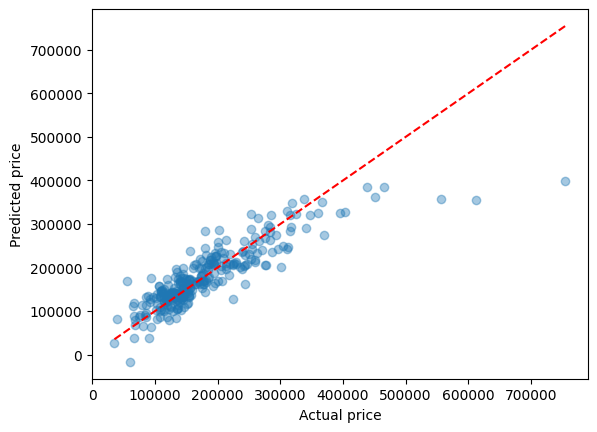

In [8]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect-prediction line
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.show()

In [9]:
for alpha in [1.0, 2.0, 10.0]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    y_pred = ridge_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Absolute Error {alpha:.4f}: {mae:.4f}")
    print(f"R² Score {alpha:.4f}: {r2:.4f}")
    print(f"RMSE {alpha:.4f}: {rmse:.4f}")


Mean Absolute Error 1.0000: 27830.9275
R² Score 1.0000: 0.7534
RMSE 1.0000: 43490.7899
Mean Absolute Error 2.0000: 27830.4727
R² Score 2.0000: 0.7533
RMSE 2.0000: 43500.9540
Mean Absolute Error 10.0000: 27866.6968
R² Score 10.0000: 0.7526
RMSE 10.0000: 43560.2527
